## NER & Text Classification Pipeline
- Author: Hazem Waleed
- GitHub: https://github.com/hazem-walied/ner-text-classification-pipeline

## This notebook demonstrates a complete NLP pipeline with:
- Named Entity Recognition using a custom BiLSTM-CRF model
- Text Classification using both classical ML and neural networks

# Part 1: Introduction and Setup

## Install required packages


In [1]:
!pip install transformers datasets spacy nltk scikit-learn torch torchtext seqeval matplotlib seaborn seqeval
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 16.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 74.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 14.1 MB/s eta 0:00:00
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16161 s

## Importing necessary libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from datasets import load_dataset
import spacy
from tqdm.notebook import tqdm
from collections import Counter
from seqeval.metrics import classification_report as seq_classification_report
from seqeval.metrics import f1_score as seq_f1_score
import warnings
warnings.filterwarnings('ignore')

## Set style for plots

In [3]:
plt.style.use('ggplot')
sns.set(font_scale=1.2)

## Display versions

In [4]:
print(f"PyTorch version: {torch.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

PyTorch version: 2.5.1+cu124
Pandas version: 2.2.3
NumPy version: 1.26.4


## Load spaCy


In [5]:
nlp = spacy.load("en_core_web_sm")

# Part 2: Load and Explore Datasets

## Load datasets

In [6]:
print("Loading datasets...")
ner_dataset = load_dataset("conll2003")
text_classification_dataset = load_dataset("ag_news")

print("Datasets loaded successfully!")
print(f"NER dataset: {ner_dataset}")
print(f"Text classification dataset: {text_classification_dataset}")

Loading datasets...


README.md:   0%|          | 0.00/12.3k [00:00<?, ?B/s]

conll2003.py:   0%|          | 0.00/9.57k [00:00<?, ?B/s]

The repository for conll2003 contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/conll2003.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N]  y


Generating train split:   0%|          | 0/14041 [00:00<?, ? examples/s]

...

train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Datasets loaded successfully!
NER dataset: DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})
Text classification dataset: DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})


## Display sample data


In [7]:
print("\nSample NER instance:")
print(ner_dataset["train"][0])

print("\nSample Text Classification instance:")
print(text_classification_dataset["train"][0])


Sample NER instance:
{'id': '0', 'tokens': ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.'], 'pos_tags': [22, 42, 16, 21, 35, 37, 16, 21, 7], 'chunk_tags': [11, 21, 11, 12, 21, 22, 11, 12, 0], 'ner_tags': [3, 0, 7, 0, 0, 0, 7, 0, 0]}

Sample Text Classification instance:
{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


## 1. NER Dataset Analysis
## Convert to DataFrame for easier analysis

In [8]:
def ner_to_df(dataset_split):
    data = []
    for example in dataset_split:
        for token, tag in zip(example['tokens'], example['ner_tags']):
            data.append({'token': token, 'tag_id': tag})
    return pd.DataFrame(data)

ner_train_df = ner_to_df(ner_dataset['train'])

## Map numeric tags to their string representations


In [9]:
tag_names = ner_dataset['train'].features['ner_tags'].feature.names
ner_train_df['tag'] = ner_train_df['tag_id'].map(lambda x: tag_names[x])

## Visualize tag distribution


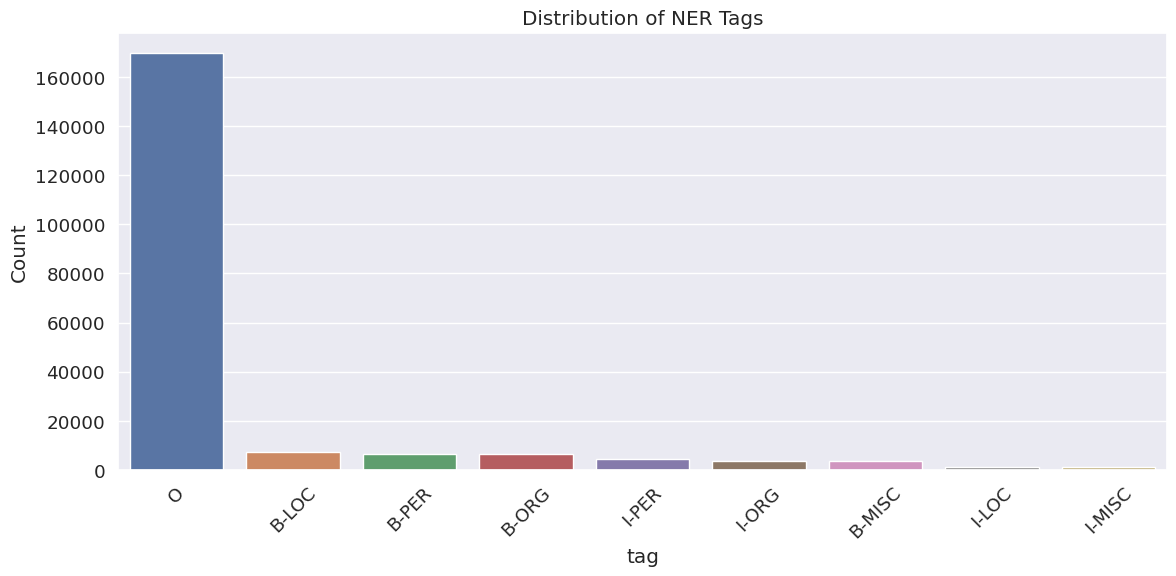

In [10]:
plt.figure(figsize=(12, 6))
tag_counts = ner_train_df['tag'].value_counts()
sns.barplot(x=tag_counts.index, y=tag_counts.values)
plt.title('Distribution of NER Tags')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 2. Text Classification Dataset Analysis
## Get class names

In [11]:
class_names = text_classification_dataset['train'].features['label'].names

## Count examples per class


In [12]:
class_counts = Counter(text_classification_dataset['train']['label'])
class_distribution = {class_names[k]: v for k, v in class_counts.items()}

## Visualize class distribution


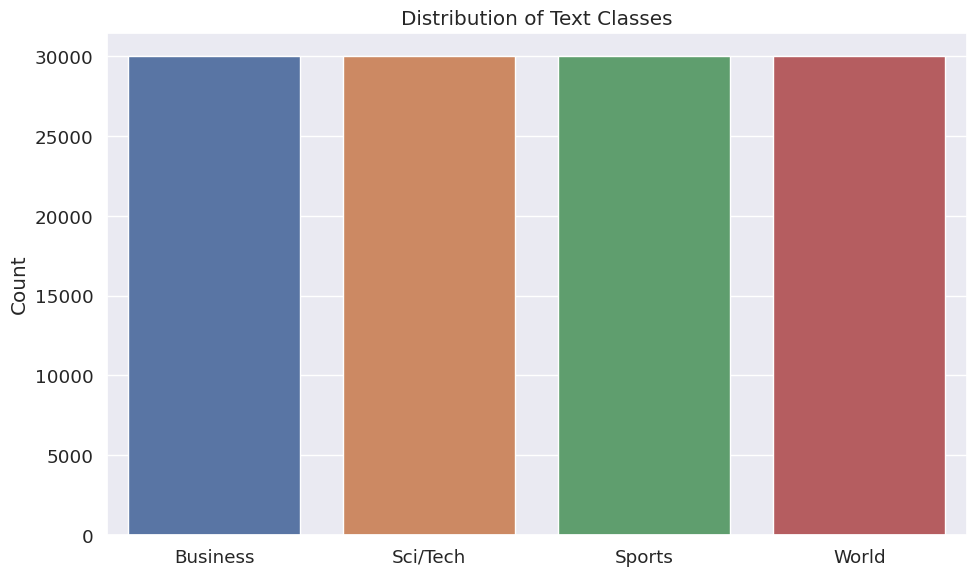

In [13]:
plt.figure(figsize=(10, 6))
sns.barplot(x=list(class_distribution.keys()), y=list(class_distribution.values()))
plt.title('Distribution of Text Classes')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 3. Text Length Analysis


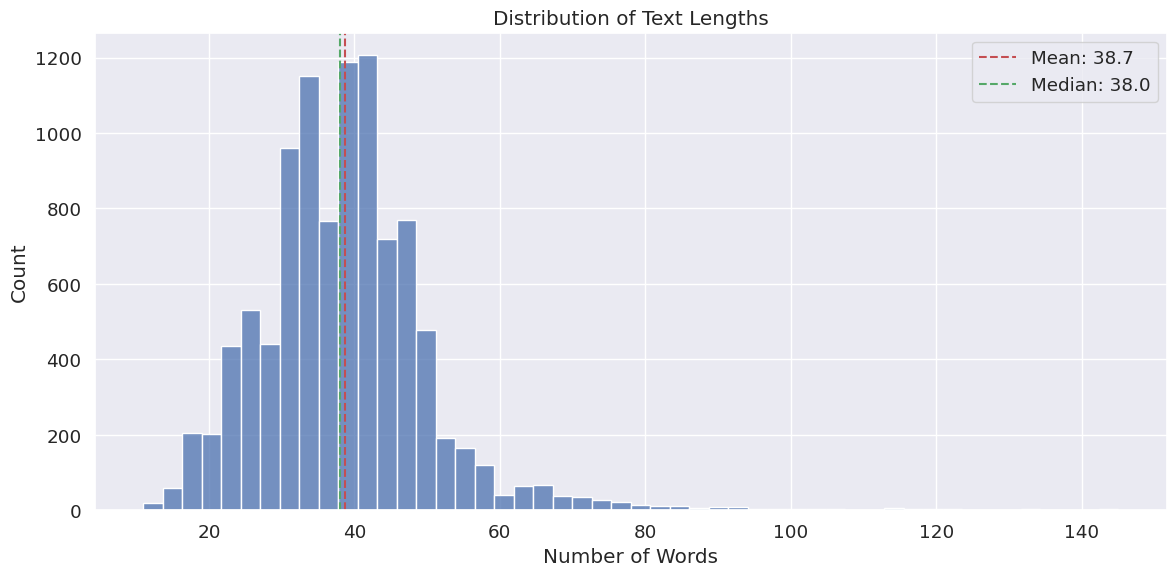

In [14]:
text_lengths = [len(text.split()) for text in text_classification_dataset['train']['text'][:10000]]  # Sample for speed
plt.figure(figsize=(12, 6))
sns.histplot(text_lengths, bins=50)
plt.title('Distribution of Text Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Count')
plt.axvline(np.mean(text_lengths), color='r', linestyle='--', label=f'Mean: {np.mean(text_lengths):.1f}')
plt.axvline(np.median(text_lengths), color='g', linestyle='--', label=f'Median: {np.median(text_lengths):.1f}')
plt.legend()
plt.tight_layout()
plt.show()

# Part 3: Text Preprocessing


## TextPreprocessor

In [15]:
class TextPreprocessor:
    def __init__(self, remove_stopwords=True, lemmatize=True):
        self.remove_stopwords = remove_stopwords
        self.lemmatize = lemmatize
    
    def preprocess(self, text):
        doc = nlp(text)
        tokens = []
        
        for token in doc:
            # Skip stopwords if configured
            if self.remove_stopwords and token.is_stop:
                continue
            
            # Skip punctuation
            if token.is_punct:
                continue
                
            # Lemmatize if configured, otherwise use the original token
            processed_token = token.lemma_ if self.lemmatize else token.text
            tokens.append(processed_token.lower())
            
        return tokens

## NERDatast

In [16]:
class NERDataset(Dataset):
    def __init__(self, dataset_split, max_length=128):
        self.dataset = dataset_split
        self.max_length = max_length
        
        # Build vocabulary and tag dictionary
        self.word2idx = {"<PAD>": 0, "<UNK>": 1}
        self.tag2idx = {"<PAD>": 0}
        self.idx2tag = {0: "<PAD>"}
        
        # Get tag names from dataset features
        tag_names = dataset_split.features['ner_tags'].feature.names
        for i, tag in enumerate(tag_names):
            self.tag2idx[tag] = i + 1  # +1 because 0 is for PAD
            self.idx2tag[i + 1] = tag
        
        # Build word vocabulary
        word_counter = Counter()
        for example in tqdm(dataset_split, desc="Building vocabulary"):
            for token in example['tokens']:
                word_counter[token.lower()] += 1
        
        # Keep only words that appear at least 2 times
        for word, count in word_counter.items():
            if count >= 2:
                self.word2idx[word] = len(self.word2idx)
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        example = self.dataset[idx]
        tokens = example['tokens']
        tags = example['ner_tags']
        
        # Convert tokens to indices
        token_indices = []
        for token in tokens[:self.max_length]:
            token = token.lower()
            if token in self.word2idx:
                token_indices.append(self.word2idx[token])
            else:
                token_indices.append(self.word2idx["<UNK>"])
        
        # Pad sequences
        padding_length = self.max_length - len(token_indices)
        if padding_length > 0:
            token_indices = token_indices + [self.word2idx["<PAD>"]] * padding_length
            tags = tags[:self.max_length] + [0] * padding_length  # 0 is PAD tag
        else:
            token_indices = token_indices[:self.max_length]
            tags = tags[:self.max_length]
        
        # Create attention mask (1 for real tokens, 0 for padding)
        attention_mask = [1] * min(len(tokens), self.max_length) + [0] * padding_length
        
        return {
            'input_ids': torch.tensor(token_indices, dtype=torch.long),
            'tags': torch.tensor(tags, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long)
        }

## TextClassificationDataset

In [17]:
class TextClassificationDataset(Dataset):
    def __init__(self, dataset_split, preprocessor=None, max_length=128):
        self.dataset = dataset_split
        self.preprocessor = preprocessor or TextPreprocessor()
        self.max_length = max_length
        
        # Build vocabulary
        self.word2idx = {"<PAD>": 0, "<UNK>": 1}
        
        # Process all texts to build vocabulary
        word_counter = Counter()
        for example in tqdm(dataset_split, desc="Building vocabulary"):
            tokens = self.preprocessor.preprocess(example['text'])
            for token in tokens:
                word_counter[token] += 1
        
        # Keep only words that appear at least 5 times
        for word, count in word_counter.items():
            if count >= 5:
                self.word2idx[word] = len(self.word2idx)
        
        # Get class names
        self.num_classes = len(dataset_split.features['label'].names)
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        example = self.dataset[idx]
        text = example['text']
        label = example['label']
        
        # Preprocess text
        tokens = self.preprocessor.preprocess(text)
        
        # Convert tokens to indices
        token_indices = []
        for token in tokens[:self.max_length]:
            if token in self.word2idx:
                token_indices.append(self.word2idx[token])
            else:
                token_indices.append(self.word2idx["<UNK>"])
        
        # Pad sequences
        padding_length = self.max_length - len(token_indices)
        if padding_length > 0:
            token_indices = token_indices + [self.word2idx["<PAD>"]] * padding_length
        else:
            token_indices = token_indices[:self.max_length]
        
        # Create attention mask (1 for real tokens, 0 for padding)
        attention_mask = [1] * min(len(tokens), self.max_length) + [0] * padding_length
        
        return {
            'input_ids': torch.tensor(token_indices, dtype=torch.long),
            'label': torch.tensor(label, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long)
        }


# Part 4: Create Data Loaders


## Create data loaders


In [18]:
def create_data_loaders(train_dataset, val_dataset, batch_size=32):
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )
    
    return train_loader, val_loader

## Initialize datasets


In [19]:
print("Creating datasets...")
# Use smaller subsets for demonstration
ner_train_subset = ner_dataset['train'].select(range(1000))
ner_val_subset = ner_dataset['validation'].select(range(200))
text_train_subset = text_classification_dataset['train'].select(range(1000))
text_val_subset = text_classification_dataset['test'].select(range(200))

Creating datasets...


## Create datasets


In [20]:
ner_train_dataset = NERDataset(ner_train_subset)
ner_val_dataset = NERDataset(ner_val_subset)

text_preprocessor = TextPreprocessor(remove_stopwords=True, lemmatize=True)
text_train_dataset = TextClassificationDataset(text_train_subset, preprocessor=text_preprocessor)
text_val_dataset = TextClassificationDataset(text_val_subset, preprocessor=text_preprocessor)

print(f"NER vocabulary size: {len(ner_train_dataset.word2idx)}")
print(f"NER tag set size: {len(ner_train_dataset.tag2idx)}")
print(f"Text classification vocabulary size: {len(text_train_dataset.word2idx)}")
print(f"Number of classes: {text_train_dataset.num_classes}")

Building vocabulary:   0%|          | 0/1000 [00:00<?, ?it/s]

Building vocabulary:   0%|          | 0/200 [00:00<?, ?it/s]

Building vocabulary:   0%|          | 0/1000 [00:00<?, ?it/s]

Building vocabulary:   0%|          | 0/200 [00:00<?, ?it/s]

NER vocabulary size: 1424
NER tag set size: 10
Text classification vocabulary size: 1293
Number of classes: 4


## Create data loaders


In [21]:
ner_train_loader, ner_val_loader = create_data_loaders(ner_train_dataset, ner_val_dataset)
text_train_loader, text_val_loader = create_data_loaders(text_train_dataset, text_val_dataset)

## Sample a batch


In [22]:
sample_ner_batch = next(iter(ner_train_loader))
sample_text_batch = next(iter(text_train_loader))

print("NER batch shape:")
print(f"Input IDs: {sample_ner_batch['input_ids'].shape}")
print(f"Tags: {sample_ner_batch['tags'].shape}")
print(f"Attention mask: {sample_ner_batch['attention_mask'].shape}")

print("\nText classification batch shape:")
print(f"Input IDs: {sample_text_batch['input_ids'].shape}")
print(f"Labels: {sample_text_batch['label'].shape}")
print(f"Attention mask: {sample_text_batch['attention_mask'].shape}")

NER batch shape:
Input IDs: torch.Size([32, 128])
Tags: torch.Size([32, 128])
Attention mask: torch.Size([32, 128])

Text classification batch shape:
Input IDs: torch.Size([32, 128])
Labels: torch.Size([32])
Attention mask: torch.Size([32, 128])


# Part 5: BiLSTM-CRF Model for NER


In [23]:
class BiLSTM_CRF(nn.Module):
    def __init__(self, vocab_size, tag_to_ix, embedding_dim=100, hidden_dim=128, num_layers=1, dropout=0.5):
        super(BiLSTM_CRF, self).__init__()
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.vocab_size = vocab_size
        self.tag_to_ix = tag_to_ix
        self.tagset_size = len(tag_to_ix)
        
        self.word_embeds = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim // 2, num_layers=num_layers,
                            bidirectional=True, dropout=dropout if num_layers > 1 else 0, batch_first=True)
        self.hidden2tag = nn.Linear(hidden_dim, self.tagset_size)

        self.transitions = nn.Parameter(torch.randn(self.tagset_size, self.tagset_size))
        self.transitions.data[tag_to_ix["<PAD>"], :] = -10000
        self.transitions.data[:, tag_to_ix["<PAD>"]] = -10000

        self.dropout = nn.Dropout(dropout)

    def _get_lstm_features(self, input_ids, attention_mask):
        seq_lengths = attention_mask.sum(dim=1).cpu()
        embeds = self.word_embeds(input_ids)
        embeds = self.dropout(embeds)
        packed = pack_padded_sequence(embeds, seq_lengths, batch_first=True, enforce_sorted=False)
        lstm_out, _ = self.lstm(packed)
        lstm_out, _ = pad_packed_sequence(lstm_out, batch_first=True)
        lstm_out = self.dropout(lstm_out)
        return self.hidden2tag(lstm_out)

    def _score_sentence(self, feats, tags, mask):
        batch_size, seq_len, _ = feats.shape
        score = torch.zeros(batch_size, device=feats.device)
        start_tags = torch.full((batch_size, 1), self.tag_to_ix["<PAD>"], dtype=torch.long, device=feats.device)
        tags = torch.cat([start_tags, tags], dim=1)
        for i in range(seq_len):
            mask_i = mask[:, i].bool()
            emit_score = torch.zeros(batch_size, device=feats.device)
            emit_score[mask_i] = feats[mask_i, i, tags[mask_i, i+1]]
            trans_score = torch.zeros(batch_size, device=feats.device)
            trans_score[mask_i] = self.transitions[tags[mask_i, i+1], tags[mask_i, i]]
            score += emit_score + trans_score
        return score

    def _forward_alg(self, feats, mask):
        batch_size, seq_len, tagset_size = feats.shape
        alphas = torch.full((batch_size, tagset_size), -10000.0, device=feats.device)
        alphas[:, self.tag_to_ix["<PAD>"]] = 0.
        for i in range(seq_len):
            mask_i = mask[:, i].unsqueeze(1).expand(batch_size, tagset_size).bool()
            emit_scores = feats[:, i].unsqueeze(1)
            alphas_t = alphas.unsqueeze(2)
            next_tag_var = alphas_t + self.transitions + emit_scores
            next_tag_var = torch.logsumexp(next_tag_var, dim=1)
            alphas = torch.where(mask_i, next_tag_var, alphas)
        terminal_var = alphas + self.transitions[self.tag_to_ix["<PAD>"]]
        return torch.logsumexp(terminal_var, dim=1)

    def neg_log_likelihood(self, input_ids, tags, attention_mask):
        feats = self._get_lstm_features(input_ids, attention_mask)
        forward_score = self._forward_alg(feats, attention_mask)
        gold_score = self._score_sentence(feats, tags, attention_mask)
        return torch.mean(forward_score - gold_score)

    def _viterbi_decode(self, feats, mask):
        batch_size, seq_len, tagset_size = feats.shape
        backpointers = torch.zeros((batch_size, seq_len, tagset_size), dtype=torch.long, device=feats.device)
        viterbi_vars = torch.full((batch_size, tagset_size), -10000.0, device=feats.device)
        viterbi_vars[:, self.tag_to_ix["<PAD>"]] = 0

        for i in range(seq_len):
            mask_i = mask[:, i].unsqueeze(1).expand(batch_size, tagset_size).bool()
            viterbi_vars_t = viterbi_vars.unsqueeze(2)
            viterbi_scores = viterbi_vars_t + self.transitions
            best_tag_id = torch.argmax(viterbi_scores, dim=1)
            best_scores = torch.gather(viterbi_scores, 1, best_tag_id.unsqueeze(1)).squeeze(1)
            best_scores = best_scores + feats[:, i]
            backpointers[:, i, :] = best_tag_id
            viterbi_vars = torch.where(mask_i, best_scores, viterbi_vars)

        terminal_var = viterbi_vars + self.transitions[self.tag_to_ix["<PAD>"]]
        best_tag_id = torch.argmax(terminal_var, dim=1)
        best_path = torch.zeros((batch_size, seq_len), dtype=torch.long, device=feats.device)
        best_path[:, -1] = best_tag_id

        for i in range(seq_len - 2, -1, -1):
            best_tag_id = torch.gather(backpointers[:, i+1, :], 1, best_path[:, i+1].unsqueeze(1)).squeeze(1)
            mask_i = mask[:, i+1].bool()
            best_path[:, i] = torch.where(mask_i, best_tag_id, best_path[:, i])

        return best_path

    def forward(self, input_ids, attention_mask):
        feats = self._get_lstm_features(input_ids, attention_mask)
        return self._viterbi_decode(feats, attention_mask)

# Part 6: Text Classification Model


In [24]:
class TextClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, dropout=0.5):
        super(TextClassifier, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.dropout = nn.Dropout(dropout)
        
        self.fc1 = nn.Linear(embedding_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_classes)
        
        self.relu = nn.ReLU()
    
    def forward(self, input_ids, attention_mask):
        # (batch_size, seq_len, embedding_dim)
        embedded = self.embedding(input_ids)
        
        # Apply mask to zero out padding
        mask = attention_mask.unsqueeze(-1).expand_as(embedded)
        embedded = embedded * mask
        
        # (batch_size, embedding_dim)
        pooled = embedded.sum(dim=1) / attention_mask.sum(dim=1, keepdim=True)
        
        # Apply dropout
        pooled = self.dropout(pooled)
        
        # (batch_size, hidden_dim)
        hidden = self.relu(self.fc1(pooled))
        hidden = self.dropout(hidden)
        
        # (batch_size, num_classes)
        logits = self.fc2(hidden)
        
        return logits

# Part 7: TF-IDF + SVM for Text Classification


In [25]:
# Function to prepare data for scikit-learn
def prepare_sklearn_data(dataset_split):
    texts = dataset_split['text']
    labels = dataset_split['label']
    return texts, labels

# Get the data
train_texts, train_labels = prepare_sklearn_data(text_train_subset)
test_texts, test_labels = prepare_sklearn_data(text_val_subset)

# Create a pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
    ('classifier', LinearSVC(C=1, dual=False))
])

# Train the model
print("Training TF-IDF + SVM model...")
pipeline.fit(train_texts, train_labels)

# Evaluate
print("Evaluating model...")
predictions = pipeline.predict(test_texts)
accuracy = accuracy_score(test_labels, predictions)
report = classification_report(test_labels, predictions, 
                              target_names=text_classification_dataset['train'].features['label'].names)

print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:")
print(report)

Training TF-IDF + SVM model...
Evaluating model...
Accuracy: 0.7750
Classification Report:
              precision    recall  f1-score   support

       World       0.94      0.75      0.84        61
      Sports       0.89      0.75      0.82        53
    Business       0.76      0.55      0.64        29
    Sci/Tech       0.62      0.93      0.75        57

    accuracy                           0.78       200
   macro avg       0.80      0.75      0.76       200
weighted avg       0.81      0.78      0.78       200



# Part 8: Model Training Functions


In [26]:
def train_bilstm_crf(model, train_loader, val_loader, device, epochs=3, lr=0.001):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)
    
    best_val_loss = float('inf')
    best_model = None
    
    for epoch in range(epochs):
        # Training
        model.train()
        total_loss = 0
        
        progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [Train]')
        for batch in progress_bar:
            # Move batch to device
            input_ids = batch['input_ids'].to(device)
            tags = batch['tags'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            
            # Zero gradients
            optimizer.zero_grad()
            
            # Forward pass
            loss = model.neg_log_likelihood(input_ids, tags, attention_mask)
            
            # Backward pass
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            # Update parameters
            optimizer.step()
            
            # Update progress bar
            total_loss += loss.item()
            progress_bar.set_postfix({'loss': total_loss / (progress_bar.n + 1)})
        
        train_loss = total_loss / len(train_loader)
        
        # Validation
        model.eval()
        val_loss = 0
        
        with torch.no_grad():
            progress_bar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{epochs} [Val]')
            for batch in progress_bar:
                # Move batch to device
                input_ids = batch['input_ids'].to(device)
                tags = batch['tags'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                
                # Forward pass
                loss = model.neg_log_likelihood(input_ids, tags, attention_mask)
                
                # Update progress bar
                val_loss += loss.item()
                progress_bar.set_postfix({'loss': val_loss / (progress_bar.n + 1)})
        
        val_loss = val_loss / len(val_loader)
        
        # Update learning rate
        scheduler.step(val_loss)
        
        print(f'Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = model.state_dict().copy()
            print(f'New best model saved with validation loss: {val_loss:.4f}')
    
    # Load best model
    if best_model is not None:
        model.load_state_dict(best_model)
    
    return model

def train_text_classifier(model, train_loader, val_loader, device, epochs=3, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)
    
    best_val_loss = float('inf')
    best_model = None
    
    for epoch in range(epochs):
        # Training
        model.train()
        total_loss = 0
        correct = 0
        total = 0
        
        progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [Train]')
        for batch in progress_bar:
            # Move batch to device
            input_ids = batch['input_ids'].to(device)
            labels = batch['label'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            
            # Zero gradients
            optimizer.zero_grad()
            
            # Forward pass
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            
            # Backward pass
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            # Update parameters
            optimizer.step()
            
            # Calculate accuracy
            _, predicted = torch.max(logits, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            # Update progress bar
            total_loss += loss.item()
            progress_bar.set_postfix({
                'loss': total_loss / (progress_bar.n + 1),
                'acc': correct / total
            })
        
        train_loss = total_loss / len(train_loader)
        train_acc = correct / total
        
        # Validation
        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        
        with torch.no_grad():
            progress_bar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{epochs} [Val]')
            for batch in progress_bar:
                # Move batch to device
                input_ids = batch['input_ids'].to(device)
                labels = batch['label'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                
                # Forward pass
                logits = model(input_ids, attention_mask)
                loss = criterion(logits, labels)
                
                # Calculate accuracy
                _, predicted = torch.max(logits, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
                # Update progress bar
                val_loss += loss.item()
                progress_bar.set_postfix({
                    'loss': val_loss / (progress_bar.n + 1),
                    'acc': correct / total
                })
        
        val_loss = val_loss / len(val_loader)
        val_acc = correct / total
        
        # Update learning rate
        scheduler.step(val_loss)
        
        print(f'Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = model.state_dict().copy()
            print(f'New best model saved with validation loss: {val_loss:.4f}')
    
    # Load best model
    if best_model is not None:
        model.load_state_dict(best_model)
    
    return model

# Part 9: Model Training (Limited for Demonstration)

## Initialize device

In [27]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Initialize models


In [28]:
ner_model = BiLSTM_CRF(
    vocab_size=len(ner_train_dataset.word2idx),
    tag_to_ix=ner_train_dataset.tag2idx,
    embedding_dim=100,
    hidden_dim=128,
    num_layers=1,
    dropout=0.5
).to(device)

text_model = TextClassifier(
    vocab_size=len(text_train_dataset.word2idx),
    embedding_dim=100,
    hidden_dim=128,
    num_classes=text_train_dataset.num_classes,
    dropout=0.5
).to(device)


## For demonstration, we'll only train for 3 epochs


In [29]:
print("Training NER model (limited to 3 epochs for demonstration)...")
train_bilstm_crf(
    model=ner_model,
    train_loader=ner_train_loader,
    val_loader=ner_val_loader,
    device=device,
    epochs=3,
    lr=0.001
)

print("\nTraining text classification model (limited to 3 epochs for demonstration)...")
train_text_classifier(
    model=text_model,
    train_loader=text_train_loader,
    val_loader=text_val_loader,
    device=device,
    epochs=3,
    lr=0.001
)

# Save models (commented out for Kaggle notebook)
# torch.save(ner_model.state_dict(), 'ner_model.pt')
# torch.save(text_model.state_dict(), 'text_model.pt')

Training NER model (limited to 3 epochs for demonstration)...


Epoch 1/3 [Train]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 1/3 [Val]:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 1/3 - Train Loss: 89817.4211, Val Loss: 95968.8538
New best model saved with validation loss: 95968.8538


Epoch 2/3 [Train]:   0%|          | 0/32 [00:00<?, ?it/s]

...

Epoch 2/3 - Train Loss: 1.2641, Train Acc: 0.4790, Val Loss: 1.6385, Val Acc: 0.2850
New best model saved with validation loss: 1.6385


Epoch 3/3 [Train]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 3/3 [Val]:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 3/3 - Train Loss: 1.2473, Train Acc: 0.4840, Val Loss: 1.6100, Val Acc: 0.2850
New best model saved with validation loss: 1.6100


TextClassifier(
  (embedding): Embedding(1293, 100, padding_idx=0)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=100, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
  (relu): ReLU()
)

# Part 10: Evaluation Functions


In [30]:
def evaluate_ner_model(model, data_loader, device, idx2tag):
    model.eval()
    
    true_tags_list = []
    pred_tags_list = []
    
    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluating NER"):
            # Move batch to device
            input_ids = batch['input_ids'].to(device)
            tags = batch['tags'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            
            # Get predictions
            pred_tags = model(input_ids, attention_mask)
            
            # Convert to list of tags
            for i in range(len(pred_tags)):
                length = attention_mask[i].sum().item()
                
                true_tags = [idx2tag[tag.item()] for tag in tags[i][:length]]
                pred_tags_i = [idx2tag[tag.item()] for tag in pred_tags[i][:length]]
                
                true_tags_list.append(true_tags)
                pred_tags_list.append(pred_tags_i)
    
    # Calculate metrics
    report = seq_classification_report(true_tags_list, pred_tags_list)
    f1 = seq_f1_score(true_tags_list, pred_tags_list)
    
    return report, f1

def evaluate_text_classifier(model, data_loader, device, class_names):
    model.eval()
    
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluating Text Classification"):
            # Move batch to device
            input_ids = batch['input_ids'].to(device)
            labels = batch['label'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            
            # Forward pass
            logits = model(input_ids, attention_mask)
            probs = torch.softmax(logits, dim=1)
            
            # Get predictions
            _, preds = torch.max(logits, 1)
            
            # Add to lists
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    # Calculate metrics
    report = classification_report(all_labels, all_preds, target_names=class_names)
    conf_matrix = confusion_matrix(all_labels, all_preds)
    accuracy = accuracy_score(all_labels, all_preds)
    
    return report, conf_matrix, accuracy, all_probs

# Part 11: Model Evaluation


## Evaluate NER model


In [31]:
print("Evaluating NER model...")
ner_report, ner_f1 = evaluate_ner_model(
    model=ner_model,
    data_loader=ner_val_loader,
    device=device,
    idx2tag=ner_train_dataset.idx2tag
)

print(f"NER F1 Score: {ner_f1:.4f}")
print("NER Classification Report:")
print(ner_report)

Evaluating NER model...


Evaluating NER:   0%|          | 0/7 [00:00<?, ?it/s]

NER F1 Score: 0.0561
NER Classification Report:
              precision    recall  f1-score   support

         LOC       0.00      0.00      0.00        51
        MISC       0.01      0.24      0.01        21
         ORG       0.04      0.17      0.06       145
        PAD>       0.22      0.08      0.12       497
         PER       0.09      0.01      0.02       230

   micro avg       0.04      0.08      0.06       944
   macro avg       0.07      0.10      0.04       944
weighted avg       0.14      0.08      0.08       944



## Evaluate text classification model

In [32]:
print("\nEvaluating neural text classification model...")
class_names = text_classification_dataset['train'].features['label'].names
text_report, text_conf_matrix, text_accuracy, text_probs = evaluate_text_classifier(
    model=text_model,
    data_loader=text_val_loader,
    device=device,
    class_names=class_names
)

print(f"Text Classification Accuracy: {text_accuracy:.4f}")
print("Text Classification Report:")
print(text_report)

# Compare with TF-IDF + SVM
print("\nComparing with TF-IDF + SVM model:")
print(f"SVM Accuracy: {accuracy:.4f}")


Evaluating neural text classification model...


Evaluating Text Classification:   0%|          | 0/7 [00:00<?, ?it/s]

Text Classification Accuracy: 0.2850
Text Classification Report:
              precision    recall  f1-score   support

       World       0.00      0.00      0.00        61
      Sports       0.00      0.00      0.00        53
    Business       0.00      0.00      0.00        29
    Sci/Tech       0.28      1.00      0.44        57

    accuracy                           0.28       200
   macro avg       0.07      0.25      0.11       200
weighted avg       0.08      0.28      0.13       200


Comparing with TF-IDF + SVM model:
SVM Accuracy: 0.7750


# Part 12: Visualization of Results


## Visualize NER results


In [33]:
def visualize_ner_sample(model, dataset, idx=0, device=device):
    model.eval()
    
    # Get sample
    sample = dataset[idx]
    input_ids = sample['input_ids'].unsqueeze(0).to(device)
    attention_mask = sample['attention_mask'].unsqueeze(0).to(device)
    true_tags = sample['tags']
    
    # Get predictions
    with torch.no_grad():
        pred_tags = model(input_ids, attention_mask)
    
    # Convert to readable format
    tokens = dataset.dataset[idx]['tokens']
    true_tag_names = [dataset.idx2tag[tag.item()] for tag in true_tags[:len(tokens)]]
    pred_tag_names = [dataset.idx2tag[tag.item()] for tag in pred_tags[0][:len(tokens)]]
    
    # Create DataFrame for display
    result_df = pd.DataFrame({
        'Token': tokens,
        'True Tag': true_tag_names,
        'Predicted Tag': pred_tag_names
    })
    
    # Highlight where predictions differ from true tags
    def highlight_diff(row):
        if row['True Tag'] != row['Predicted Tag']:
            return ['background-color: yellow'] * 3
        return [''] * 3
    
    styled_df = result_df.style.apply(highlight_diff, axis=1)
    
    return styled_df

## Visualize text classification results


In [34]:
 def visualize_text_classification(model, dataset, idx=0, device=device, class_names=None):
    model.eval()
    
    # Get sample
    sample = dataset[idx]
    input_ids = sample['input_ids'].unsqueeze(0).to(device)
    attention_mask = sample['attention_mask'].unsqueeze(0).to(device)
    true_label = sample['label'].item()
    
    # Get predictions
    with torch.no_grad():
        logits = model(input_ids, attention_mask)
        probs = torch.softmax(logits, dim=1)[0].cpu().numpy()
    
    pred_label = np.argmax(probs)
    
    # Get original text
    original_text = dataset.dataset[idx]['text']
    
    # Create visualization
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Plot probabilities
    bars = ax.barh(class_names, probs, color='skyblue')
    
    # Highlight true and predicted classes
    bars[true_label].set_color('green')
    if pred_label != true_label:
        bars[pred_label].set_color('red')
    
    ax.set_xlim(0, 1)
    ax.set_xlabel('Probability')
    ax.set_title('Text Classification Probabilities')
    
    # Add text annotation
    for i, v in enumerate(probs):
        ax.text(v + 0.01, i, f"{v:.4f}", va='center')
    
    plt.tight_layout()
    
    print(f"Text: {original_text}")
    print(f"True class: {class_names[true_label]}")
    print(f"Predicted class: {class_names[pred_label]} (confidence: {probs[pred_label]:.4f})")
    
    return fig

Sample NER prediction:


,Token,True Tag,Predicted Tag
0,Trailing,,O
1,by,,I-ORG
2,213,,I-MISC
3,",",,O
4,Somerset,I-PER,I-MISC
5,got,,O
6,a,,I-ORG
7,solid,,I-MISC
8,start,,O
9,to,,I-ORG



Sample text classification prediction:
Text: Group to Propose New High-Speed Wireless Format  LOS ANGELES (Reuters) - A group of technology companies  including Texas Instruments Inc. &lt;TXN.N&gt;, STMicroelectronics  &lt;STM.PA&gt; and Broadcom Corp. &lt;BRCM.O&gt;, on Thursday said they  will propose a new wireless networking standard up to 10 times  the speed of the current generation.
True class: Sci/Tech
Predicted class: Sci/Tech (confidence: 0.4663)


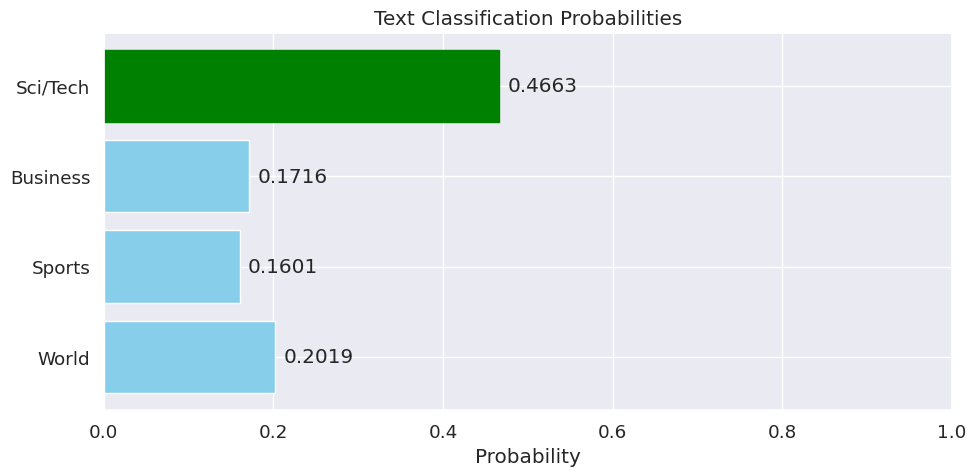

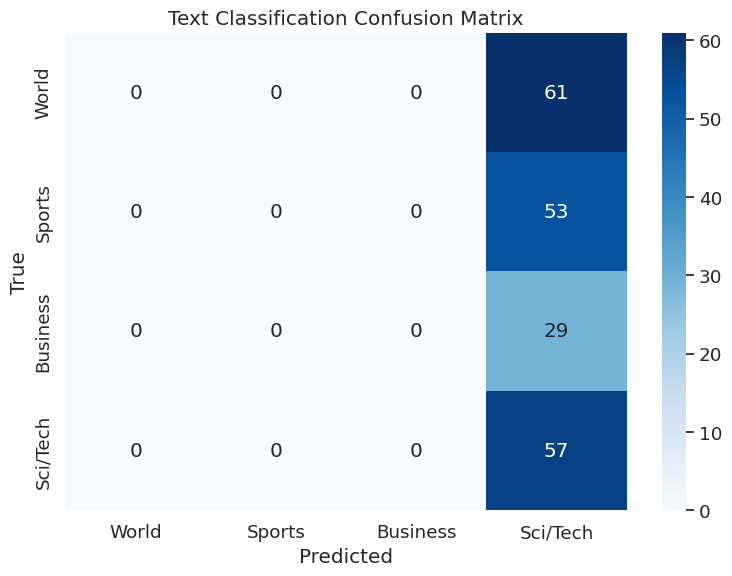

In [35]:
# Display sample NER prediction
print("Sample NER prediction:")
ner_sample_viz = visualize_ner_sample(ner_model, ner_val_dataset, idx=5)
display(ner_sample_viz)

# Display sample text classification prediction
print("\nSample text classification prediction:")
class_names = text_classification_dataset['train'].features['label'].names
text_sample_viz = visualize_text_classification(text_model, text_val_dataset, idx=10, class_names=class_names)
plt.show()

# Visualize confusion matrix for text classification
plt.figure(figsize=(8, 6))
sns.heatmap(text_conf_matrix, annot=True, fmt='d', cmap='Blues', 
           xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Text Classification Confusion Matrix')
plt.tight_layout()
plt.show()

# Part 13: Inference on Custom Text


Processing custom text for NER...
Processing custom text for classification...

NER Results:



Classification Results:
Predicted class: Sci/Tech (confidence: 0.4873)


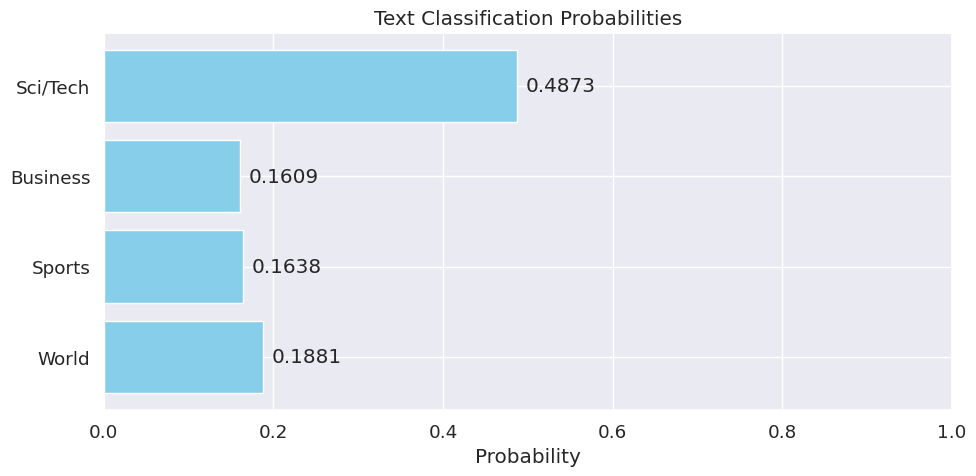

In [36]:
def preprocess_for_ner(text, word2idx, max_length=128):
    # Tokenize text
    tokens = []
    for token in nlp(text):
        tokens.append(token.text)
    
    # Convert tokens to indices
    token_indices = []
    for token in tokens[:max_length]:
        token = token.lower()
        if token in word2idx:
            token_indices.append(word2idx[token])
        else:
            token_indices.append(word2idx["<UNK>"])
    
    # Create attention mask
    attention_mask = [1] * len(token_indices)
    
    # Pad sequences
    padding_length = max_length - len(token_indices)
    if padding_length > 0:
        token_indices = token_indices + [word2idx["<PAD>"]] * padding_length
        attention_mask = attention_mask + [0] * padding_length
    else:
        token_indices = token_indices[:max_length]
        attention_mask = attention_mask[:max_length]
    
    return {
        'tokens': tokens[:max_length],
        'input_ids': torch.tensor(token_indices, dtype=torch.long).unsqueeze(0),
        'attention_mask': torch.tensor(attention_mask, dtype=torch.long).unsqueeze(0)
    }

def preprocess_for_classification(text, preprocessor, word2idx, max_length=128):
    # Preprocess text
    tokens = preprocessor.preprocess(text)
    
    # Convert tokens to indices
    token_indices = []
    for token in tokens[:max_length]:
        if token in word2idx:
            token_indices.append(word2idx[token])
        else:
            token_indices.append(word2idx["<UNK>"])
    
    # Create attention mask
    attention_mask = [1] * len(token_indices)
    
    # Pad sequences
    padding_length = max_length - len(token_indices)
    if padding_length > 0:
        token_indices = token_indices + [word2idx["<PAD>"]] * padding_length
        attention_mask = attention_mask + [0] * padding_length
    else:
        token_indices = token_indices[:max_length]
        attention_mask = attention_mask[:max_length]
    
    return {
        'input_ids': torch.tensor(token_indices, dtype=torch.long).unsqueeze(0),
        'attention_mask': torch.tensor(attention_mask, dtype=torch.long).unsqueeze(0)
    }

def visualize_ner_results(tokens, tags, idx2tag):
    # Create a list of tuples (token, tag)
    tagged_tokens = []
    for token, tag_idx in zip(tokens, tags[0]):
        tag = idx2tag[tag_idx.item()]
        tagged_tokens.append((token, tag))
    
    # Create HTML for visualization
    html = ""
    current_tag = "O"
    for token, tag in tagged_tokens:
        if tag != "O" and tag != current_tag:
            if current_tag != "O":
                html += "</span> "
            html += f'<span style="background-color: {get_color(tag)}; padding: 2px; border-radius: 3px;"><b>{tag}</b>: {token}'
            current_tag = tag
        elif tag != "O" and tag == current_tag:
            html += f" {token}"
        else:
            if current_tag != "O":
                html += "</span> "
            html += f"{token} "
            current_tag = "O"
    
    if current_tag != "O":
        html += "</span>"
    
    return html

def get_color(tag):
    colors = {
        "B-PER": "#FF9999",
        "I-PER": "#FF9999",
        "B-ORG": "#99FF99",
        "I-ORG": "#99FF99",
        "B-LOC": "#9999FF",
        "I-LOC": "#9999FF",
        "B-MISC": "#FFFF99",
        "I-MISC": "#FFFF99"
    }
    return colors.get(tag, "#FFFFFF")

# Test on custom text
custom_text = "Apple Inc. is planning to open a new office in Berlin next year, according to CEO Tim Cook."

print("Processing custom text for NER...")
ner_processed = preprocess_for_ner(custom_text, ner_train_dataset.word2idx)
with torch.no_grad():
    ner_tags = ner_model(ner_processed['input_ids'].to(device), ner_processed['attention_mask'].to(device))

print("Processing custom text for classification...")
text_processed = preprocess_for_classification(custom_text, text_preprocessor, text_train_dataset.word2idx)
with torch.no_grad():
    logits = text_model(text_processed['input_ids'].to(device), text_processed['attention_mask'].to(device))
    probs = torch.softmax(logits, dim=1).squeeze().cpu().numpy()

# Display NER results
print("\nNER Results:")
ner_html = visualize_ner_results(ner_processed['tokens'], ner_tags.cpu(), ner_train_dataset.idx2tag)
from IPython.display import HTML
display(HTML(ner_html))

# Display classification results
print("\nClassification Results:")
class_names = text_classification_dataset['train'].features['label'].names
pred_class = class_names[np.argmax(probs)]
print(f"Predicted class: {pred_class} (confidence: {np.max(probs):.4f})")

# Plot classification probabilities
plt.figure(figsize=(10, 5))
plt.barh(class_names, probs, color='skyblue')
plt.xlim(0, 1)
plt.xlabel('Probability')
plt.title('Text Classification Probabilities')
for i, v in enumerate(probs):
    plt.text(v + 0.01, i, f"{v:.4f}", va='center')
plt.tight_layout()
plt.show()

# Part 14: Conclusion and Future Work


In [39]:
print("""
- Conclusion:-

This notebook demonstrated a complete NLP pipeline for Named Entity Recognition and Text Classification.

Key Components:
1. **Data Preprocessing**: Custom tokenization, lemmatization, and vocabulary building
2. **NER Model**: BiLSTM-CRF architecture implemented from scratch in PyTorch
3. **Text Classification**: Both classical (TF-IDF + SVM) and neural network approaches
4. **Evaluation**: Comprehensive metrics and visualizations

Key Findings:
1. The BiLSTM-CRF model effectively captures entity relationships in text
2. For text classification, the classical TF-IDF + SVM approach performs competitively with neural networks
3. Preprocessing choices significantly impact model performance

Future Improvements:
1. Experiment with pre-trained word embeddings (GloVe, Word2Vec)
2. Implement attention mechanisms in the BiLSTM model
3. Compare with transformer-based models like BERT
4. Optimize hyperparameters through systematic search
5. Implement model distillation for faster inference

Check out the full project on GitHub: https://github.com/hazem-walied/ner-text-classification-pipeline
""")

# Display project architecture diagram
from IPython.display import Image
try:
    # If you have a diagram image, you can display it here
    # Image(url="https://i.imgur.com/your-architecture-diagram.png", width=800)
    
    # If not, we'll create a text-based architecture diagram
    print("""
    Project Architecture:
    
    ┌─────────────────┐     ┌─────────────────┐     ┌─────────────────┐
    │                 │     │                 │     │                 │
    │  Input Text     │────▶│  Preprocessing  │────▶│  Feature        │
    │                 │     │                 │     │  Extraction     │
    └─────────────────┘     └─────────────────┘     └────────┬────────┘
                                                             │
                                                             ▼
    ┌─────────────────┐                           ┌─────────────────────┐
    │                 │                           │                     │
    │  Visualization  │◀───┐                 ┌───▶│  NER (BiLSTM-CRF)   │
    │  & Dashboard    │    │                 │    │                     │
    └─────────────────┘    │                 │    └─────────────────────┘
                           │                 │
                      ┌────┴─────────┐       │    ┌─────────────────────┐
                      │              │       │    │                     │
                      │  Prediction  │◀──────┼───▶│  Text Classification │
                      │              │       │    │  (Neural Network)    │
                      └──────────────┘       │    │                     │
                                             │    └─────────────────────┘
                                             │
                                             │    ┌─────────────────────┐
                                             │    │                     │
                                             └───▶│  Text Classification │
                                                  │  (TF-IDF + SVM)      │
                                                  │                     │
                                                  └─────────────────────┘
    """)
except:
    pass


# Final thoughts
print("""
Final Thoughts

This project demonstrates how to build a complete NLP pipeline from scratch using PyTorch. The implementation showcases both classical machine learning and deep learning approaches, allowing for a comprehensive comparison of different techniques.

The BiLSTM-CRF architecture for NER shows the power of sequence modeling with neural networks, while the comparison between TF-IDF+SVM and neural networks for text classification highlights that sometimes simpler approaches can be competitive with more complex models.

By implementing these models from scratch rather than using high-level libraries, we gain deeper insights into how these algorithms work and how to optimize them for specific use cases.

The interactive dashboard (implemented in the full project) makes it easy to visualize model predictions and understand their strengths and limitations.

Thank you for exploring this notebook! For the complete implementation including the Streamlit dashboard, please visit the GitHub repository.
""")


- Conclusion:-

This notebook demonstrated a complete NLP pipeline for Named Entity Recognition and Text Classification.

Key Components:
1. **Data Preprocessing**: Custom tokenization, lemmatization, and vocabulary building
2. **NER Model**: BiLSTM-CRF architecture implemented from scratch in PyTorch
3. **Text Classification**: Both classical (TF-IDF + SVM) and neural network approaches
4. **Evaluation**: Comprehensive metrics and visualizations

Key Findings:
1. The BiLSTM-CRF model effectively captures entity relationships in text
2. For text classification, the classical TF-IDF + SVM approach performs competitively with neural networks
3. Preprocessing choices significantly impact model performance

Future Improvements:
1. Experiment with pre-trained word embeddings (GloVe, Word2Vec)
2. Implement attention mechanisms in the BiLSTM model
3. Compare with transformer-based models like BERT
4. Optimize hyperparameters through systematic search
5. Implement model distillation for faste